# Homework 3

## Problem 1

Implement serial test and apply to a `samples`

Статистические гипотезы:
- H0: распределение равномерное
- H1: распределение не является равномерным

In [102]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

def serial_test(samples, k = 10, min_expected = 5):
    expected = (len(samples) // 2) / (k * k)
    pairs = [(samples[2 * i], samples[2 * i + 1]) for i in range(len(samples) // 2)]
    observed = np.zeros((k, k), dtype = int)

    for x, y in pairs:
        i = int(x * k)
        j = int(y * k)
        if i == k:
            i = k - 1
        if j == k:
            j = k - 1
        observed[i, j] += 1

    f_obs = observed.reshape(-1)
    f_exp = np.full(k * k, expected)
    result = stats.chisquare(f_obs, f_exp)
    return result


rng.current = 1
samples = [rng() for _ in range(1000)]

result = serial_test(samples, 10)
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Reject H0")
else:
    print("Do not reject H0")

Statistic: 114.39999999999999
p-value: 0.1380441495447643
Do not reject H0


## Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [103]:
import matplotlib.pyplot as plt

def rng_bad(m = 2 ** 31, a = 65539, c = 0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def rng_good(m = 2 ** 32, a = 1103515245, c = 12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m


def serial_test_3D(sample, k = 12, min_expected = 5):
    expected = (len(sample) // 3) / (k * k * k)
    triples = [(sample[3 * i], sample[3 * i + 1], sample[3 * i + 2]) for i
               in range(len(sample) // 3)]
    observed = np.zeros((k, k, k), dtype = int)

    for x, y, z, in triples:
        i = int(x * k)
        j = int(y * k)
        l = int(z * k)
        if i == k: i = k - 1
        if j == k: j = k - 1
        if l == k: l = k - 1
        observed[i, j, l] += 1

    f_obs = observed.reshape(-1)
    f_exp = np.full(k * k * k, expected)
    result = stats.chisquare(f_obs, f_exp)
    return result

rng_bad.current = 1
rng_good.current = 1
bad_samples = [rng_bad() for _ in range(30000)]
good_samples = [rng_good() for _ in range(30000)]
result_bad = serial_test_3D(bad_samples, 12)
result_good = serial_test_3D(good_samples, 12)
print('rng_bad: statistic:', result_bad.statistic)
print('rng_bad: p-value:', result_bad.pvalue)
print(f"rng_bad: uniform distribution: {result_bad.pvalue > 0.05}")
print()
print('rng_bad: statistic:', result_good.statistic)
print('rng_bad: p-value:', result_good.pvalue)
print(f"rng_bad: uniform distribution: {result_good.pvalue > 0.05}")


rng_bad: statistic: 2398.3999999999996
rng_bad: p-value: 8.058511637780739e-25
rng_bad: uniform distribution: False

rng_bad: statistic: 1643.6096
rng_bad: p-value: 0.9237882775997049
rng_bad: uniform distribution: True


## Problem 4

Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

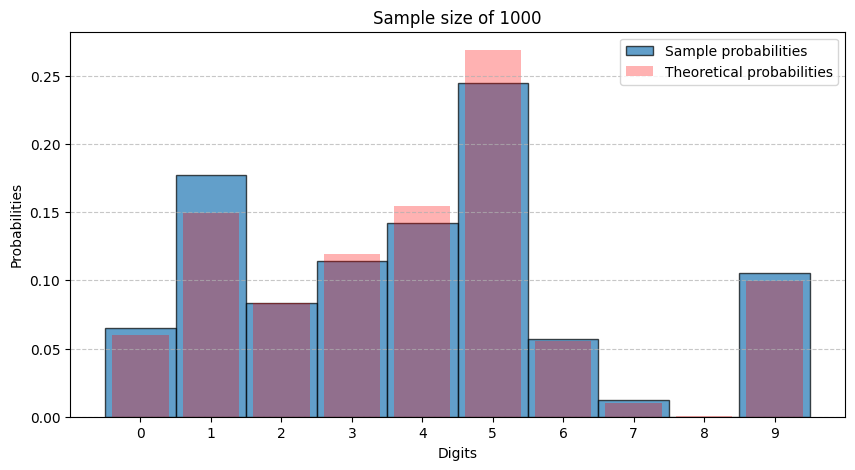

In [104]:
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
digits = np.arange(10)

probs = weights / weights.sum()

sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
sorted_digits = digits[sorted_indices]

cum_probs = np.cumsum(sorted_probs)


n_points = 1000
u = np.random.rand(n_points)
sample = []

for value in u:
    idx = np.searchsorted(cum_probs, value)
    sample.append(sorted_digits[idx])

sample = np.array(sample)

plt.figure(figsize=(10, 5))
plt.hist(sample, bins=np.arange(-0.5, 10.5, 1), density=True, alpha=0.7, edgecolor='black', label='Sample probabilities')
plt.xticks(digits)
plt.title("Sample size of 1000")
plt.xlabel("Digits")
plt.ylabel("Probabilities")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.bar(digits, probs, alpha=0.3, color='red', label='Theoretical probabilities')
plt.legend()
plt.show()

## Problem 5

Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

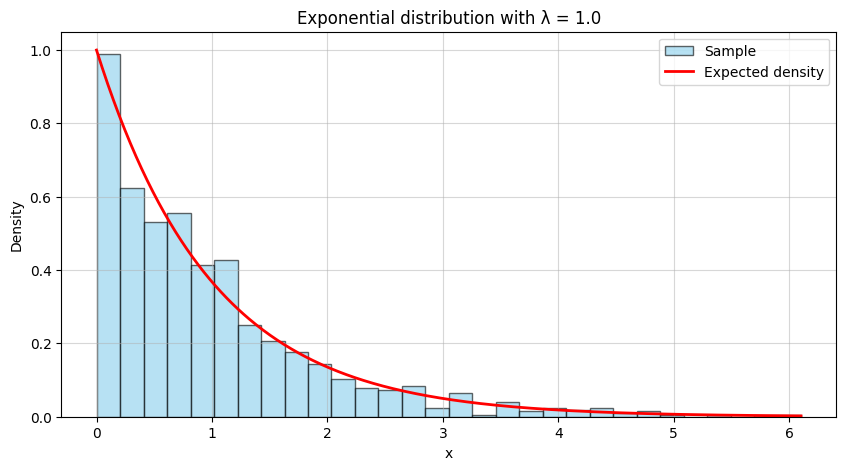

In [105]:
lambda_parametr = 1.0
n = 1000
u = np.random.rand(n)
x = -np.log(1 - u) / lambda_parametr


plt.figure(figsize=(10, 5))
plt.hist(x, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample')

x_plot = np.linspace(0, np.max(x), 500)
pdf = lambda_parametr * np.exp(-lambda_parametr * x_plot)
plt.plot(x_plot, pdf, 'r-', linewidth=2, label='Expected density')

plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Exponential distribution with λ = {lambda_parametr}')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

## Problem 6

Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

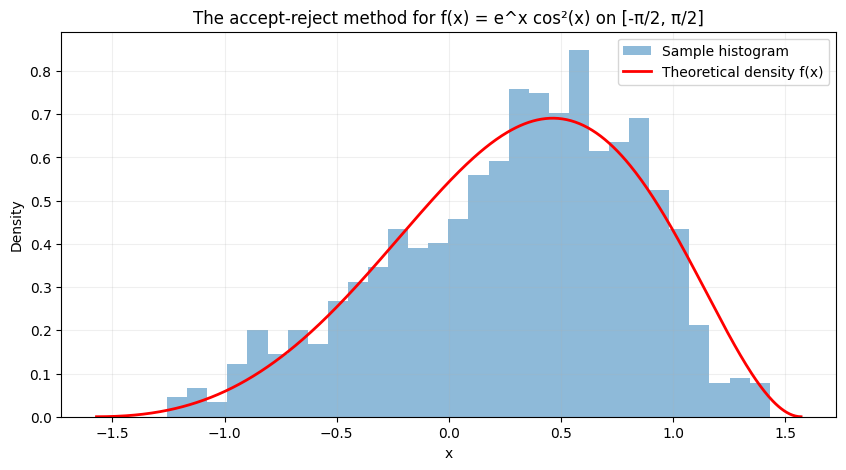

In [106]:
from scipy.optimize import minimize_scalar
from scipy.integrate import quad

def f_unnorm(x):
    return np.exp(x) * (np.cos(x))**2

a = -np.pi/2
b = np.pi/2


res = minimize_scalar(lambda x: -f_unnorm(x), bounds=(a, b), method='bounded')
max_f = f_unnorm(res.x)
M = max_f * (b - a) * 1.01


def sample_accept_reject(n, a, b, M):
    samples = []
    while len(samples) < n:
        y = np.random.uniform(a, b)
        u = np.random.rand()
        if u <= f_unnorm(y) / (M * 1/(b-a)):
            samples.append(y)
    return np.array(samples)

np.random.seed(42)
sample = sample_accept_reject(1000, a, b, M)

x_plot = np.linspace(a, b, 500)
Z, _ = quad(f_unnorm, a, b)
f_true = f_unnorm(x_plot) / Z

plt.figure(figsize=(10,5))
plt.hist(sample, bins=30, density=True, alpha=0.5, label='Sample histogram')
plt.plot(x_plot, f_true, 'r-', lw=2, label='Theoretical density f(x)')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('The accept-reject method for f(x) = e^x cos²(x) on [-π/2, π/2]')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Problem 7

Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

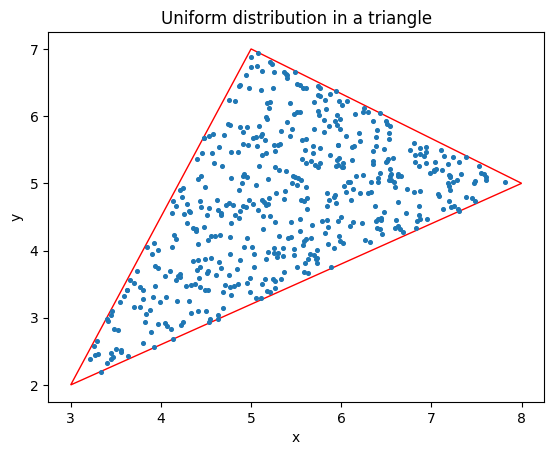

In [107]:
from matplotlib.patches import Polygon

def sample_triangle_reflection(n, seed = 1):
    np.random.seed(seed)
    u = np.random.rand(n)
    v = np.random.rand(n)

    mask = (u + v > 1)
    u[mask] = 1 - u[mask]
    v[mask] = 1 - v[mask]
    points = A + u.reshape(-1, 1) * (B - A) + v.reshape(-1, 1) * (C - A)
    return points

A = np.array([5, 7])
B = np.array([3, 2])
C = np.array([8, 5])

samples = sample_triangle_reflection(500, seed = 1)

fig, ax = plt.subplots()
triangle = Polygon([A, B, C], closed = True, fill = False, edgecolor = "red")
ax.add_patch(triangle)
ax.scatter(samples[:, 0], samples[:, 1], s = 7)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Uniform distribution in a triangle")
plt.show()

## Problem 8

Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

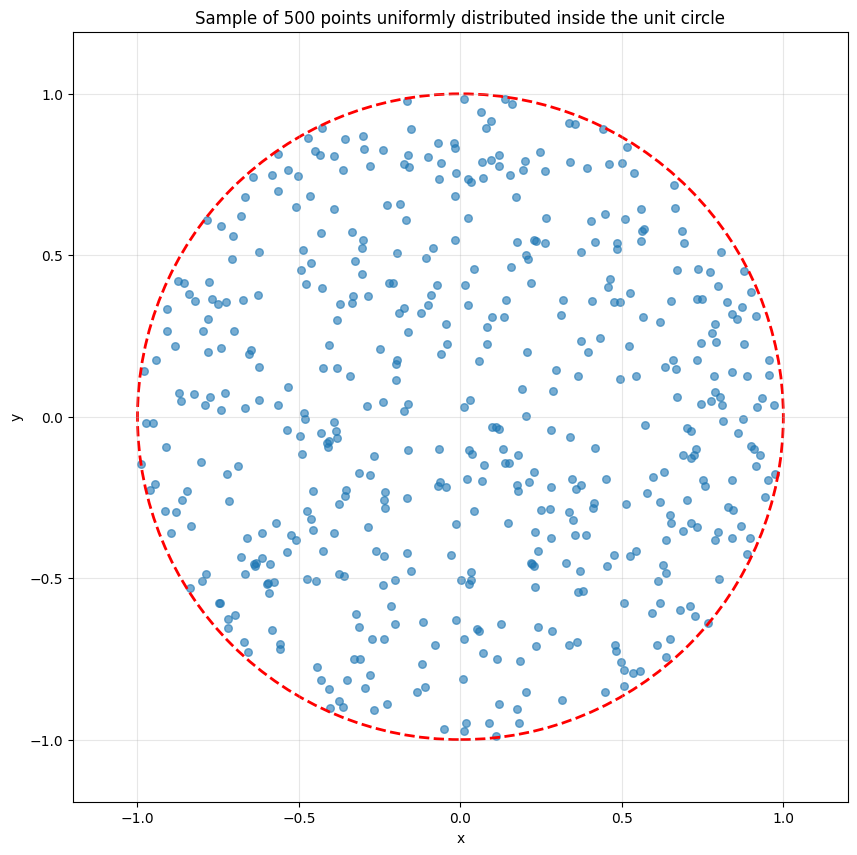

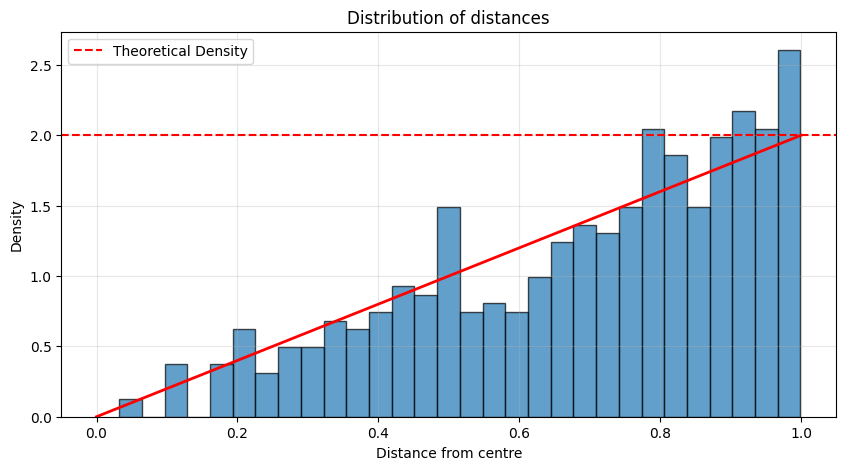

In [108]:
n_points = 500

theta = 2 * np.pi * np.random.random(n_points)
radius = np.sqrt(np.random.random(n_points))

x = radius * np.cos(theta)
y = radius * np.sin(theta)

plt.figure(figsize=(10, 10))
plt.scatter(x, y, alpha=0.6, s=30)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title('Sample of 500 points uniformly distributed inside the unit circle')
plt.xlabel('x')
plt.ylabel('y')

circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--', linewidth=2)
plt.gca().add_patch(circle)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.show()


plt.figure(figsize=(10, 5))
plt.hist(radius, bins=30, density=True, alpha=0.7, edgecolor='black')
plt.axhline(y=2, color='red', linestyle='--', label='Theoretical Density')
r_theor = np.linspace(0, 1, 100)
plt.plot(r_theor, 2*r_theor, 'r-', linewidth=2)
plt.xlabel('Distance from centre')
plt.ylabel('Density')
plt.title('Distribution of distances')
plt.legend()
plt.grid(True, alpha=0.3)

## Problem 9

Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

Mean: [4 7]
Sample mean: [3.98734042 6.84995416]
Covariance matrix:
  20.0    -4.0
  -4.0    40.0
Sample covariance matrix:
  19.7    -3.8
  -3.8    41.0


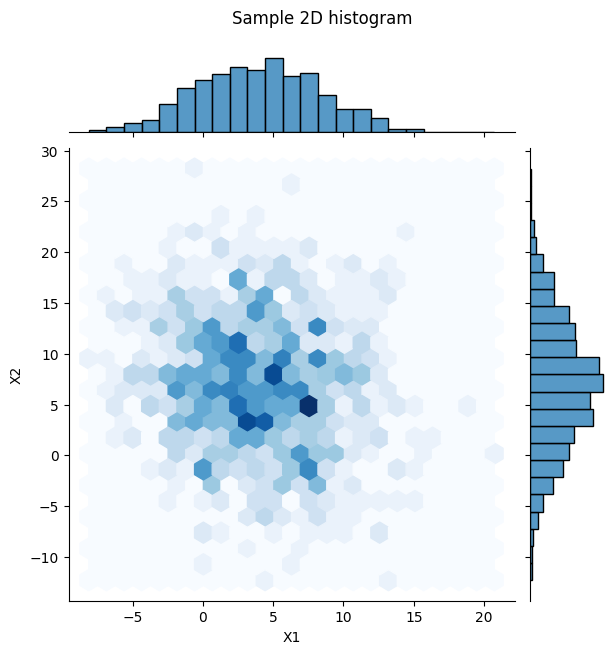

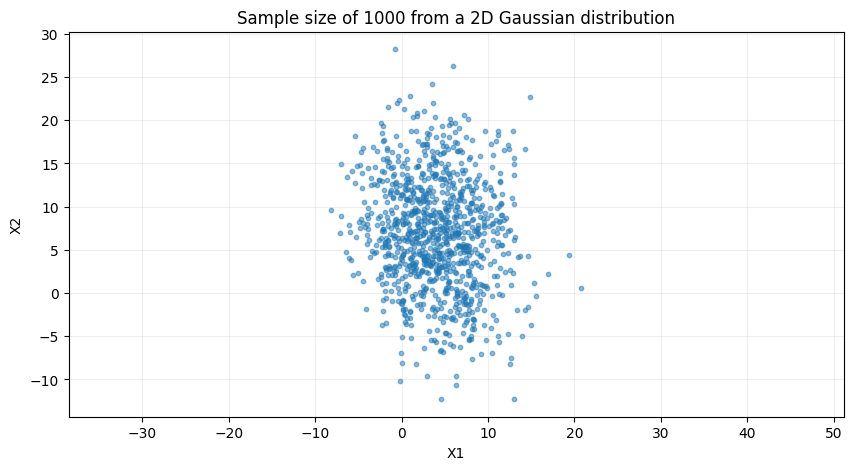

In [109]:
import seaborn as sns
from scipy.linalg import cholesky


def box_muller_polar(n):
    z = np.zeros((n, 2))
    for i in range(n):
        while True:
            u = 2 * np.random.rand() - 1
            v = 2 * np.random.rand() - 1
            s = u**2 + v**2
            if 0 < s < 1:
                break
        c = np.sqrt(-2 * np.log(s) / s)
        z[i, 0] = u * c
        z[i, 1] = v * c
    return z


mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])
n_samples = 1000


Z = box_muller_polar(n_samples)
L = cholesky(Sigma, lower=True)
X = mu + Z @ L.T

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)


print("Mean:", mu)

print("Sample mean:", sample_mean)


print("Covariance matrix:")
for i in range(Sigma.shape[0]):
    row = "  ".join(f"{Sigma[i, j]:6.1f}" for j in range(Sigma.shape[1]))
    print(row)

print("Sample covariance matrix:")
for i in range(sample_cov.shape[0]):
    row = "  ".join(f"{sample_cov[i, j]:6.1f}" for j in range(sample_cov.shape[1]))
    print(row)



joint_plot = sns.jointplot(x=X[:, 0], y=X[:, 1], kind='hex', bins=30, cmap='Blues')
joint_plot.set_axis_labels('X1', 'X2')
plt.suptitle('Sample 2D histogram', y=1.05)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Sample size of 1000 from a 2D Gaussian distribution')
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()